In [16]:
import pandas as pd
df = pd.read_csv('unlabel.csv')
df = df.drop(columns=['pseudo_label'])
df.to_csv('unlabeled.csv', index=False)

In [8]:
import pandas as pd

# Preview Labeled training data
label_preview = pd.read_csv('label.csv')
label_preview.head()

,text,label
0,Statement: Forty percent of the Fortune 500 we...,False
1,Statement: Farouk is on fire.\r\nSpeaker: j-xa...,True
2,Statement: Shutdowns are a normal part of the ...,False
3,Statement: Says Donald Trump says he has forei...,False
4,Statement: Phoenix is already one of the kidna...,False


# LIAR Dataset - Data Exploration
## Fake News Detection Dataset

Dataset gồm 2 cột:
- `text`: Prompt đã gom tất cả features (statement + speaker + party + topic + analysis)
- `label`: Binary classification ('true' hoặc 'false')

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Data

In [10]:
# Load datasets (current LIAR splits)
import pandas as pd

# Read CSVs in the current folder
df_label = pd.read_csv('label.csv')        # real labels
df_unlabel = pd.read_csv('unlabel.csv')    # pseudo labels (0/1)
df_test = pd.read_csv('test.csv')          # real labels
df_val = pd.read_csv('val.csv')            # real labels

# Normalize real labels to 'true'/'false' strings
for d in (df_label, df_test, df_val):
    if 'label' in d.columns:
        d['label'] = d['label'].astype(str).str.lower()

# Prepare pseudo label string for unlabel set for consistent analysis
if 'pseudo_label' in df_unlabel.columns:
    df_unlabel['pseudo_label'] = df_unlabel['pseudo_label'].astype(int)
    df_unlabel['label'] = df_unlabel['pseudo_label'].map({1: 'true', 0: 'false'})

print("📊 Dataset sizes:")
print(f"Labeled:  {len(df_label):,} samples")
print(f"Unlabeled:{len(df_unlabel):,} samples")
print(f"Test:     {len(df_test):,} samples")
print(f"Val:      {len(df_val):,} samples")

📊 Dataset sizes:
Labeled:  10 samples
Unlabeled:10,232 samples
Test:     1,267 samples
Val:      1,284 samples


## 2. Data Overview

In [11]:
# Overview of labeled training set
print("📋 Labeled dataset info:")
print(df_label.info())
print("\n" + "="*60)
print("\n📋 Columns:")
print(df_label.columns.tolist())
print("\n📋 First 3 rows:")
df_label.head(3)

📋 Labeled dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    10 non-null     object
 1   label   10 non-null     object
dtypes: object(2)
memory usage: 292.0+ bytes
None


📋 Columns:
['text', 'label']

📋 First 3 rows:


,text,label
0,Statement: Forty percent of the Fortune 500 we...,false
1,Statement: Farouk is on fire.\r\nSpeaker: j-xa...,true
2,Statement: Shutdowns are a normal part of the ...,false


## 3. Label Distribution

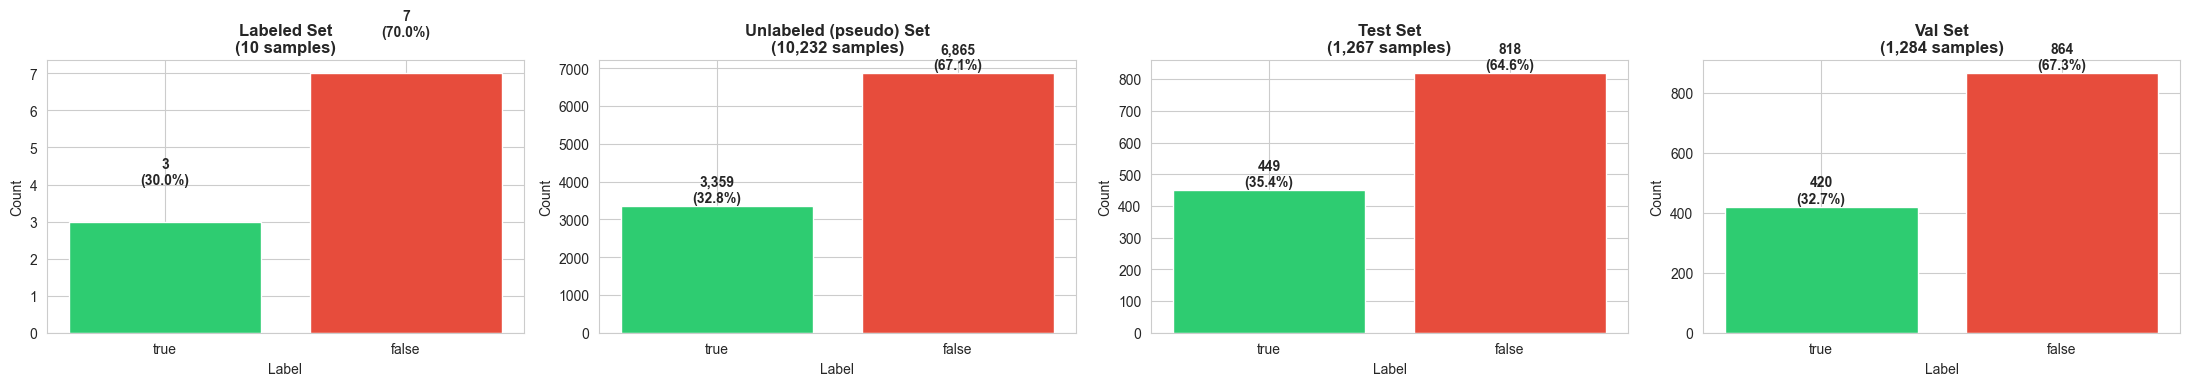


📊 Label Distribution (counts and %):

Labeled:
label
false    7
true     3
Name: count, dtype: int64
Percentage:
label
false    70.0
true     30.0
Name: proportion, dtype: float64

Unlabeled (pseudo):
label
false    6865
true     3359
Name: count, dtype: int64
Percentage:
label
false    67.15
true     32.85
Name: proportion, dtype: float64

Test:
label
false    818
true     449
Name: count, dtype: int64
Percentage:
label
false    64.56
true     35.44
Name: proportion, dtype: float64

Val:
label
false    864
true     420
Name: count, dtype: int64
Percentage:
label
false    67.29
true     32.71
Name: proportion, dtype: float64


In [12]:
# Label distribution across splits
fig, axes = plt.subplots(1, 4, figsize=(22, 4))

def plot_counts(ax, df, name, col='label'):
    counts = df[col].value_counts().reindex(['true', 'false']).fillna(0).astype(int)
    ax.bar(counts.index, counts.values, color=['#2ecc71', '#e74c3c'])
    ax.set_title(f'{name} Set\n({len(df):,} samples)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Label')
    ax.set_ylabel('Count')
    total = len(df)
    for i, (lbl, cnt) in enumerate(counts.items()):
        if total > 0:
            pct = cnt / total * 100
            ax.text(i, cnt + max(1, total*0.01), f'{cnt:,}\n({pct:.1f}%)', ha='center', fontweight='bold')

plot_counts(axes[0], df_label, 'Labeled')
plot_counts(axes[1], df_unlabel, 'Unlabeled (pseudo)')
plot_counts(axes[2], df_test, 'Test')
plot_counts(axes[3], df_val, 'Val')

plt.tight_layout()
plt.show()

print("\n📊 Label Distribution (counts and %):")
for name, df in [('Labeled', df_label), ('Unlabeled (pseudo)', df_unlabel), ('Test', df_test), ('Val', df_val)]:
    print(f"\n{name}:")
    print(df['label'].value_counts())
    print("Percentage:")
    print((df['label'].value_counts(normalize=True) * 100).round(2))

## 4. Text Length Analysis

📏 Text Length Statistics:

Train:
count    10242.000000
mean       629.104765
std        321.289155
min         65.000000
25%        470.000000
50%        598.000000
75%        742.000000
max       9661.000000
Name: text_length, dtype: float64


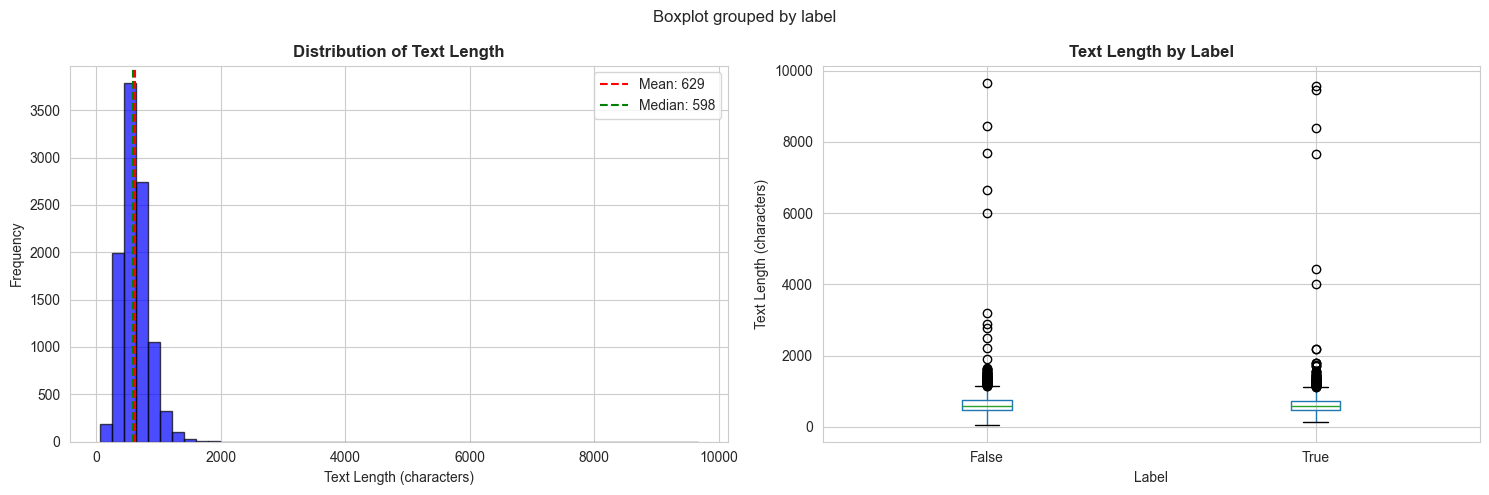

In [ ]:
# Text length analysis on labeled data only (can extend if needed)
for df, name in [(df_label, 'Labeled')]:
    df['text_length'] = df['text'].str.len()

print("📏 Text Length Statistics (Labeled):")
print(df_label['text_length'].describe())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].hist(df_label['text_length'], bins=50, alpha=0.7, color='blue', edgecolor='black')
axes[0].axvline(df_label['text_length'].mean(), color='red', linestyle='--', label=f"Mean: {df_label['text_length'].mean():.0f}")
axes[0].axvline(df_label['text_length'].median(), color='green', linestyle='--', label=f"Median: {df_label['text_length'].median():.0f}")
axes[0].set_xlabel('Text Length (characters)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Text Length (Labeled)', fontweight='bold')
axes[0].legend()

df_label.boxplot(column='text_length', by='label', ax=axes[1])
axes[1].set_title('Text Length by Label (Labeled)', fontweight='bold')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Text Length (characters)')
plt.suptitle("")
plt.tight_layout()
plt.show()

## 5. Sample Examples

In [ ]:
# Sample examples from labeled set
print("=" * 80)
print("📰 EXAMPLE: TRUE Statement")
print("=" * 80)
true_rows = df_label[df_label['label'] == 'true']
if len(true_rows) > 0:
    true_sample = true_rows.iloc[0]
    print(true_sample['text'])
    print(f"\n✅ Label: {true_sample['label']}")
else:
    print("No 'true' samples found in labeled set.")

print("\n" + "=" * 80)
print("📰 EXAMPLE: FALSE Statement")
print("=" * 80)
false_rows = df_label[df_label['label'] == 'false']
if len(false_rows) > 0:
    false_sample = false_rows.iloc[0]
    print(false_sample['text'])
    print(f"\n❌ Label: {false_sample['label']}")
else:
    print("No 'false' samples found in labeled set.")

📰 EXAMPLE: TRUE Statement


IndexError: single positional indexer is out-of-bounds

## 6. Random Samples

In [ ]:
# Random samples from labeled set
print("🎲 Random Samples from Labeled Set:\n")

for i, row in df_label.sample(min(3, len(df_label))).iterrows():
    print("=" * 80)
    print(f"Sample index {i}")
    print("=" * 80)
    print(row['text'])
    print(f"\nLabel: {row['label']}")
    if 'text_length' in df_label.columns:
        print(f"Length: {row['text_length']} characters")
    print()

🎲 Random Samples from Training Set:

Sample 7731
Statement: A former Clinton administration official and other economists agree that if you keep extending these temporary unemployment benefits, youre just going to extend joblessness even more.
Speaker: michelle-malkin (none party)
Topic: economy,pundits,stimulus

Analysis: McAuliffes ad says, "Cuccinelli wants to make all abortion illegal, even in cases of rape and incest, even to protect a womans health. "Cuccinelli is an adamant opponent of abortion, but he has consistently supported one rare exception: Allowing abortion when a mothers life is endangered by pregnancy. His position was known to McAuliffes campaign and incongruously cited in its news release announcing the ad. Its not easy to overstate Cuccinellis objections to abortion, but McAuliffes ad manages to do just that.

Label: False
Length: 792 characters

Sample 1787
Statement: President Obama has the most border patrols and border security deployed at the border of any pre

## 7. Word Count Analysis

📊 Word Count Statistics:
count    10242.000000
mean        96.833626
std         45.091581
min         10.000000
25%         71.000000
50%         92.000000
75%        116.000000
max       1142.000000
Name: word_count, dtype: float64


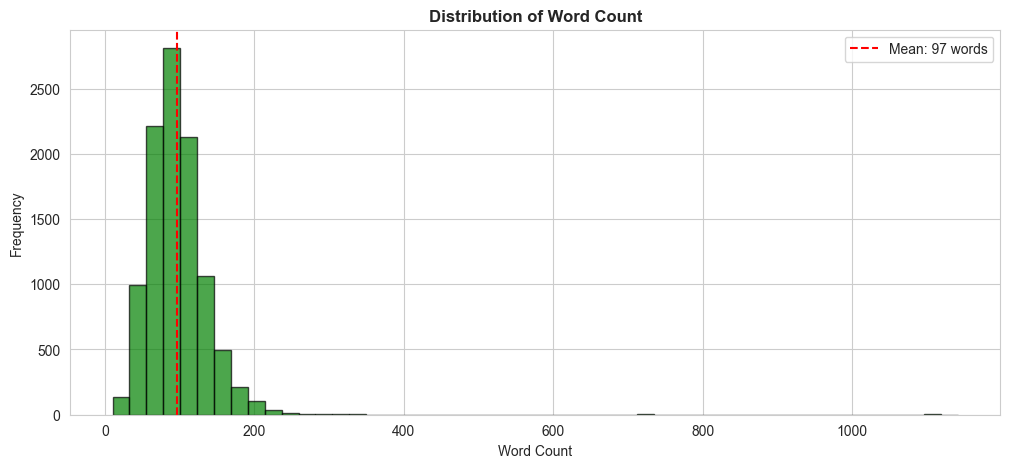

In [ ]:
# Word count analysis (Labeled)
df_label['word_count'] = df_label['text'].str.split().str.len()

print("📊 Word Count Statistics (Labeled):")
print(df_label['word_count'].describe())

plt.figure(figsize=(12, 5))
plt.hist(df_label['word_count'], bins=50, alpha=0.7, color='green', edgecolor='black')
plt.axvline(df_label['word_count'].mean(), color='red', linestyle='--', label=f"Mean: {df_label['word_count'].mean():.0f} words")
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.title('Distribution of Word Count (Labeled)', fontweight='bold')
plt.legend()
plt.show()

## 8. Quick Search Function

In [ ]:
def search_samples(keyword, n=3, source='labeled'):
    """Search samples containing keyword in chosen source: 'labeled', 'unlabeled', 'test', 'val'"""
    source_map = {
        'labeled': df_label,
        'unlabeled': df_unlabel,
        'test': df_test,
        'val': df_val
    }
    if source not in source_map:
        raise ValueError("source must be one of: labeled, unlabeled, test, val")
    data = source_map[source]
    results = data[data['text'].str.contains(keyword, case=False, na=False)]
    print(f"🔍 Found {len(results)} samples containing '{keyword}' in {source} set\n")
    for i, (idx, row) in enumerate(results.head(n).iterrows()):
        print("=" * 80)
        print(f"Result {i+1}/{min(n, len(results))} (index {idx})")
        print("=" * 80)
        print(row['text'][:500] + "..." if len(row['text']) > 500 else row['text'])
        print(f"\nLabel: {row['label']}")
        print()

# Example usage
search_samples('Obama', n=2, source='labeled')

🔍 Found 2628 samples containing 'Obama'

Result 1/2
Statement: Hillary Clinton agrees with John McCain "by voting to give George Bush the benefit of the doubt on Iran."
Speaker: barack-obama (democrat party)
Topic: foreign-policy

Analysis: Obama said he would have voted against the amendment if he had been present. So though Clinton may have "agreed" with McCain on the issue, they did not technically vote the same way on it. To say that voting for Kyl-Lieberman is "giving George Bush the benefit of the doubt on Iran" remains a contentious issue....

Label: True

Result 2/2
Statement: I'm the only person on this stage who has worked actively just last year passing, along with Russ Feingold, some of the toughest ethics reform since Watergate.
Speaker: barack-obama (democrat party)
Topic: ethics

Analysis: However, it was not that bill, but another one, sponsored by Majority Leader Harry Reid and introduced five days earlier on Jan.  4, 2007 that eventually became law. Obama was not a co

## 9. Summary Statistics

In [ ]:
print("" * 80)
print("📊 DATASET SUMMARY")
print("=" * 80)

summary = pd.DataFrame({
    'Split': ['Labeled', 'Unlabeled (pseudo)', 'Test', 'Val', 'Total'],
    'Samples': [
        len(df_label),
        len(df_unlabel),
        len(df_test),
        len(df_val),
        len(df_label) + len(df_unlabel) + len(df_test) + len(df_val)
    ]
})

# Compute true/false counts for each split
true_counts = [
    (df_label['label'] == 'true').sum(),
    (df_unlabel['label'] == 'true').sum(),
    (df_test['label'] == 'true').sum(),
    (df_val['label'] == 'true').sum(),
    None
]
false_counts = [
    (df_label['label'] == 'false').sum(),
    (df_unlabel['label'] == 'false').sum(),
    (df_test['label'] == 'false').sum(),
    (df_val['label'] == 'false').sum(),
    None
]

summary['True'] = true_counts[:-1] + [sum(true_counts[:-1])]
summary['False'] = false_counts[:-1] + [sum(false_counts[:-1])]

summary['% True'] = (summary['True'] / summary['Samples'] * 100).round(1)
summary['% False'] = (summary['False'] / summary['Samples'] * 100).round(1)

print(summary.to_string(index=False))
print("=" * 80)


📊 DATASET SUMMARY
Split  Samples  True  False  % True  % False
Train    10242     0      0     0.0      0.0
 Test     1267     0      0     0.0      0.0
  Val     1284     0      0     0.0      0.0
Total    12793     0      0     0.0      0.0


In [3]:
# === Align real labels from backup.csv to unlabel.csv ===
import pandas as pd
from pathlib import Path

# Read source files (assumes current working dir is the LIAR folder)
backup_df = pd.read_csv('backup.csv')            # Contains real labels (True/False strings)
unlabel_df = pd.read_csv('unlabel.csv')          # Contains pseudo_label (0/1)

print(f"Original backup size: {len(backup_df):,}")
print(f"Unlabel size: {len(unlabel_df):,}")

# Normalize real labels to lowercase 'true'/'false'
backup_df['label'] = backup_df['label'].astype(str).str.lower()

# Handle potential duplicate texts with conflicting labels by majority vote
label_mode = (backup_df
              .groupby('text')['label']
              .agg(lambda s: s.mode().iat[0])
              .reset_index())

# Merge to align order exactly as in unlabel.csv
aligned = unlabel_df.merge(label_mode, on='text', how='left')
aligned = aligned.rename(columns={'label': 'real_label'})

missing = aligned['real_label'].isna().sum()
if missing:
    print(f"WARNING: {missing} texts in unlabel.csv not found in backup.csv")
else:
    print("All texts in unlabel.csv found in backup.csv ✅")

assert len(aligned) == len(unlabel_df), "Row count mismatch after merge."

# Sanity: ensure ordering preserved (merge preserves unlabel order by default)
print("Aligned dataframe shape:", aligned.shape)
print(aligned.head(3))

# Save the new file with real labels corresponding to unlabel set
output_path = Path('unlabel_with_real_label.csv')
aligned[['text','real_label']].to_csv(output_path, index=False)
print(f"Saved aligned real labels to: {output_path}")

# Distribution comparison (pseudo vs real)
if 'pseudo_label' in aligned.columns:
    pseudo_dist = aligned['pseudo_label'].value_counts().rename('pseudo_count')
    real_dist = aligned['real_label'].value_counts().rename('real_count')
    dist = pd.concat([pseudo_dist, real_dist], axis=1)
    print("\nLabel distribution (pseudo vs real):")
    print(dist)

# Map pseudo 0/1 to string for quick discrepancy check
pseudo_map = aligned['pseudo_label'].map({1:'true', 0:'false'})
label_diff = (pseudo_map != aligned['real_label']).sum()
print(f"Discrepant labels between pseudo and real: {label_diff:,} / {len(aligned):,}")

Original backup size: 10,242
Unlabel size: 10,232
All texts in unlabel.csv found in backup.csv ✅
Aligned dataframe shape: (10232, 3)
                                                text  pseudo_label real_label
0  Statement: Says the Annies List political grou...             0      false
1  Statement: When did the decline of coal start?...             1      false
2  Statement: Hillary Clinton agrees with John Mc...             1       true
Saved aligned real labels to: unlabel_with_real_label.csv

Label distribution (pseudo vs real):
        pseudo_count  real_count
0             6865.0         NaN
1             3359.0         NaN
500              1.0         NaN
8                1.0         NaN
6832             1.0         NaN
2196             1.0         NaN
32               1.0         NaN
3                1.0         NaN
2012             1.0         NaN
198019           1.0         NaN
false            NaN      6597.0
true             NaN      3635.0
Discrepant labels between pseu

In [14]:
# === Overwrite 'label' with numeric 1/0 and save new CSVs ===
import pandas as pd
from pathlib import Path

label_map = {'true': 1, 'false': 0}

def overwrite_and_save(df, filename, label_column='label', overwrite=True):
    out_df = df.copy()
    if label_column in out_df.columns:
        # Map to numeric; keep original values that don't match as is
        out_df[label_column] = out_df[label_column].map(lambda x: label_map.get(str(x).lower(), x))
        # Sanity check for unmapped values
        if out_df[label_column].isin(['true','false']).any():
            leftovers = out_df[out_df[label_column].isin(['true','false'])][label_column].unique()
            print(f"WARNING: Unmapped leftover labels present: {leftovers}")
    out_path = Path(filename)
    if out_path.exists() and not overwrite:
        print(f"Skip (exists): {out_path}")
    else:
        out_df.to_csv(out_path, index=False)
        print(f"Saved: {out_path} ({len(out_df):,} rows)")
        # Print distribution if numeric
        if out_df[label_column].dtype != 'O':
            print(out_df[label_column].value_counts())
    return out_df

# Overwrite labels directly when exporting
overwrite_and_save(df_label, 'label_numeric.csv')
overwrite_and_save(df_test, 'test_numeric.csv')
overwrite_and_save(df_val, 'val_numeric.csv')

# Unlabeled already numeric in pseudo_label; ensure label column numeric too
if 'label' in df_unlabel.columns:
    if df_unlabel['label'].dtype == 'O':
        df_unlabel['label'] = df_unlabel['label'].map(lambda x: label_map.get(str(x).lower(), x))
    df_unlabel.to_csv('unlabel_numeric.csv', index=False)
    print(f"Saved: unlabel_numeric.csv ({len(df_unlabel):,} rows)")

# Real label aligned file if exists
try:
    aligned_real = pd.read_csv('unlabel_with_real_label.csv')
    if 'real_label' in aligned_real.columns:
        aligned_real['real_label'] = aligned_real['real_label'].map(lambda x: label_map.get(str(x).lower(), x))
        aligned_real.to_csv('unlabel_with_real_label_numeric.csv', index=False)
        print(f"Saved: unlabel_with_real_label_numeric.csv ({len(aligned_real):,} rows)")
        print(aligned_real['real_label'].value_counts())
except FileNotFoundError:
    print("unlabel_with_real_label.csv not found; skip numeric real label conversion.")

print("Done overwriting label columns with numeric values.")

Saved: label_numeric.csv (10 rows)
label
0    7
1    3
Name: count, dtype: int64
Saved: test_numeric.csv (1,267 rows)
label
0    818
1    449
Name: count, dtype: int64
Saved: val_numeric.csv (1,284 rows)
label
0    864
1    420
Name: count, dtype: int64
Saved: unlabel_numeric.csv (10,232 rows)
unlabel_with_real_label.csv not found; skip numeric real label conversion.
Done overwriting label columns with numeric values.
